# Tier 3: WCL 改良系アブレーション — 再掲ベースライン + フル再計算

本ノートは以下を自己完結で行う（Run All で全計算が走る）：

1. 公表ベースライン（PBL / CLA / WCL）の再掲
2. Tier 3 の5手法 — `wcl_powerdomain` / `wcl_topl` / `wcl_blacklist` / `wcl_varweight` / `wcl_linpower` — の解説とデモ
3. Protocol A（2 fold）・LOLO（59 fold）のフル再計算
4. 凍結済み `results/*.csv` との数値照合

実装は複製せず、`icsr8`（`icsr8.methods.run_method` / `icsr8.harness` の公開関数）を import して利用する。

## 1. 概要

`doc/final_report/main.tex` で凍結されたベースラインは、生 RSSI から再現した公表値
（Protocol A・往路 Ave, backward→forward fold）である：

| 手法 | Ave [m]（往路） |
|---|---|
| PBL | 4.38 |
| CLA | 8.07 |
| WCL | 3.57 |

WCL はこの中で最良のベースラインであり、Tier 1〜3 の改善手法はすべて WCL（または
その指紋パイプライン）を出発点とする。

**Tier 3** は「WCL の重み関数・候補入力だけを差し替えるアブレーション群」
（`doc/final_report/main.tex` §3.1、手法6–12の一部）であり、狙いは大きな精度改善ではなく
*WCL の何を変えると何が起きるか* を切り分けることにある。本ノートで扱う5手法は：

- **wcl_powerdomain**（手法8）: 重みを $w=10^{r/10}$（最小値減算なし）に変更 — 数学的に WCL と**同値**であることを確認する ablation。
- **wcl_topl**（手法9）: 上位 $L\in\{3,4,5,7,\text{all}\}$ の AP 数を訓練誤差で自動選択する一般化。
- **wcl_blacklist**（手法10）: 廊下外に設置された AP-C0-3F-04 を候補プールから除外。
- **wcl_varweight**（手法11）: RSSI 分散と検出回数に基づく信頼度で重みを補正。
- **wcl_linpower**（手法12）: per-scan 集約を中央値から線形電力平均 $10\log_{10}(\overline{10^{r/10}})$ に変更。

いずれも WCL の**凸包制約**（推定点が使用 AP 座標の凸包内に留まる幾何的な根本問題）
は保持したまま、重みと入力候補の妥当性を測る基準として位置づけられる
（`doc/final_report/main.tex` §5「実装手法」3.1節）。

In [1]:
%matplotlib inline
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from icsr8.constants import RANDOM_SEED, BLACKLIST_APS
from icsr8.evaluate import l2_errors, summary
from icsr8.fingerprint import candidate_aggregate, candidate_medians, reproduction_fingerprint
from icsr8.harness import run_lolo, run_protocol_a
from icsr8.io import load_ap_coords, load_location_coords, load_raw_scans
from icsr8.methods import run_method
from icsr8.methods.wcl_topl import WCLTopL
from icsr8.methods.wcl_varweight import WclVarweight
from icsr8.protocols import iter_protocol_a

# notebooks/ から実行しても repo ルートからでも動くように解決する（os.chdir は使わない）。
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = REPO / "data" / "dataset"
RAWDATA_ROOT = REPO / "data" / "rawdata"
RESULTS_DIR = REPO / "results"

SEED = RANDOM_SEED
B = 1000  # bootstrap resamples (icsr8.harness の既定値と一致させる)

BASELINE_METHODS = ["pbl", "cla", "wcl"]
TIER3_METHODS = ["wcl_powerdomain", "wcl_topl", "wcl_blacklist", "wcl_varweight", "wcl_linpower"]
METHODS = BASELINE_METHODS + TIER3_METHODS

timings: dict[str, float] = {}
t_notebook_start = time.perf_counter()
print(f"対象手法: {METHODS}")

対象手法: ['pbl', 'cla', 'wcl', 'wcl_powerdomain', 'wcl_topl', 'wcl_blacklist', 'wcl_varweight', 'wcl_linpower']


## 2. データ読み込み

`notebooks/` からの相対パスで `data/dataset`（AP座標・地点座標）と
`data/rawdata`（forward/backward 生スキャン）を読み込む。

In [2]:
t0 = time.perf_counter()
ap13 = load_ap_coords(DATASET_DIR / "AP_coordinate_C3F.csv")
truth = load_location_coords(DATASET_DIR / "location_coordinate_C.csv")[["location_p", "x", "y"]]
scans_f = load_raw_scans("forward", RAWDATA_ROOT)
scans_b = load_raw_scans("backward", RAWDATA_ROOT)
timings["data_load"] = time.perf_counter() - t0

print(f"AP (3F, 13台): {len(ap13)}")
print(f"地点数: {len(truth)}")
print(f"forward scans: {len(scans_f)} 行, backward scans: {len(scans_b)} 行")
ap13.head()

AP (3F, 13台): 13
地点数: 59
forward scans: 16659 行, backward scans: 17432 行


,ap_name,floor,x,y,z
0,AP-C0-3F-01,3,30.1,1.0,9.7
1,AP-C0-3F-02,3,20.8,-1.1,9.7
2,AP-C0-3F-03,3,9.1,1.0,9.7
3,AP-C0-3F-04,3,-1.9,-11.2,9.7
4,AP-C1-3F-01,3,31.5,15.8,9.7


## 3. wcl_powerdomain ≡ wcl の数学的同値性

ベースライン WCL の重み（上位3候補、$r_{\min}$ はその中の最小 RSSI）:
$$w_j = 10^{(r_j - r_{\min})/10}.$$
`wcl_powerdomain`（手法8）はこれを
$$w_j' = 10^{r_j/10} = w_j \cdot 10^{-r_{\min}/10}$$
に差し替える。両者は定数因子 $10^{-r_{\min}/10}$ しか違わない。重心の正規化
$$\hat{\mathbf{x}} = \frac{\sum_j w_j \mathbf{x}_j}{\sum_j w_j}$$
では、この定数因子が分子・分母の双方に一様にかかるため厳密に相殺し、
$$\hat{\mathbf{x}}' = \frac{\sum_j w_j' \mathbf{x}_j}{\sum_j w_j'}
  = \frac{10^{-r_{\min}/10}\sum_j w_j \mathbf{x}_j}{10^{-r_{\min}/10}\sum_j w_j}
  = \hat{\mathbf{x}}$$
となる。つまり **wcl と wcl_powerdomain は数式のレベルで同一の推定値を返す**。
浮動小数点の演算順序が異なるため厳密なビット一致にはならないが、以下で実データ
（Protocol A の両 fold、59地点 × 2）を用いて per-location の座標差を直接計算し、
機械精度に収まる（$\ll 1\times10^{-12}$ m）ことを確認する — 本ノートの見どころ。

In [3]:
t0 = time.perf_counter()
folds_a = iter_protocol_a(scans_f, scans_b)

max_diff_by_fold = {}
diff_frames = []
for fold in folds_a:
    est_wcl = run_method("wcl", fold.train_scans, fold.test_scans, ap13, truth)
    est_pd = run_method("wcl_powerdomain", fold.train_scans, fold.test_scans, ap13, truth)
    merged = est_wcl.merge(est_pd, on="location_p", suffixes=("_wcl", "_pd"))
    diff = np.hypot(merged["x_wcl"] - merged["x_pd"], merged["y_wcl"] - merged["y_pd"])
    max_diff_by_fold[fold.name] = float(diff.max())
    diff_frames.append(merged.assign(diff=diff, fold=fold.name))

diff_all = pd.concat(diff_frames, ignore_index=True)
overall_max_diff = float(diff_all["diff"].max())
timings["equivalence_check"] = time.perf_counter() - t0

print("fold別 per-location 最大座標差 [m]:")
for name, d in max_diff_by_fold.items():
    print(f"  {name}: {d:.3e}")
print(f"\n全体（{len(diff_all)} 地点 x fold）の最大差: {overall_max_diff:.3e} m")

assert overall_max_diff < 1e-12, f"equivalence broke: max diff = {overall_max_diff}"
print("\n=> 実データで確認: per-location 最大差 < 1e-12 m。wcl_powerdomain は wcl と数学的に同値。")

fold別 per-location 最大座標差 [m]:
  forward_to_backward: 2.161e-14
  backward_to_forward: 1.446e-14

全体（118 地点 x fold）の最大差: 2.161e-14 m

=> 実データで確認: per-location 最大差 < 1e-12 m。wcl_powerdomain は wcl と数学的に同値。


## 4. 各手法のデモ

Tier 3 の各手法が baseline WCL から何を変えているかを、`icsr8.methods.run_method`
の公開エントリと `icsr8.fingerprint` の公開関数だけを用いて確認する
（推定器の内部を再実装せず、公開 API 呼び出しの結果を観察する）。
以下では Protocol A の forward→backward fold を共通の観察対象に使う。

In [4]:
# --- 4a. wcl_topl: L の自動選択 -------------------------------------------
fold_fb = folds_a[0]  # forward -> backward
train_locs_f = truth[truth["location_p"].isin(scans_f["location_p"].unique())]

topl_auto = WCLTopL(L=None).fit(scans_f, ap13, train_locs_f)
print(f"訓練データ（forward pool、訓練誤差基準）上の自動選択: L = {topl_auto.selected_L!r}")

rows = []
for L in (3, 4, 5, 7, "all"):
    est = run_method("wcl_topl", fold_fb.train_scans, fold_fb.test_scans, ap13, truth, L=L)
    err = l2_errors(est, truth[truth["location_p"].isin(est["location_p"])])
    rows.append({"L": L, "test_ave_error_m": summary(err["error"])["Ave"]})
topl_L_table = pd.DataFrame(rows)
topl_L_table

訓練データ（forward pool、訓練誤差基準）上の自動選択: L = 3


,L,test_ave_error_m
0,3,3.512499
1,4,3.512785
2,5,3.497811
3,7,3.507516
4,all,3.509581


In [5]:
# --- 4b. wcl_blacklist: 除外される AP ---------------------------------------
cand_f = candidate_medians(scans_f, ap13)
loc_with_blacklisted_ap = sorted(
    cand_f.loc[cand_f["ap_name"].isin(BLACKLIST_APS), "location_p"].unique()
)
print(f"BLACKLIST_APS = {sorted(BLACKLIST_APS)}")
print(
    f"forward pool でこの AP が候補に現れる地点数: "
    f"{len(loc_with_blacklisted_ap)} / {truth['location_p'].nunique()}"
)

demo_loc = int(loc_with_blacklisted_ap[0])
before = reproduction_fingerprint(cand_f[cand_f["location_p"] == demo_loc])
after = reproduction_fingerprint(
    cand_f[(cand_f["location_p"] == demo_loc) & (~cand_f["ap_name"].isin(BLACKLIST_APS))]
)
print(f"\n地点 P{demo_loc}: 除外前 {len(before)} AP -> 除外後 {len(after)} AP")

est_wcl_all = run_method("wcl", fold_fb.train_scans, fold_fb.test_scans, ap13, truth)
est_bl_all = run_method("wcl_blacklist", fold_fb.train_scans, fold_fb.test_scans, ap13, truth)
truth_demo = truth[truth["location_p"] == demo_loc]
err_wcl_demo = l2_errors(
    est_wcl_all[est_wcl_all["location_p"] == demo_loc], truth_demo
)["error"].iloc[0]
err_bl_demo = l2_errors(
    est_bl_all[est_bl_all["location_p"] == demo_loc], truth_demo
)["error"].iloc[0]
print(f"地点 P{demo_loc} の誤差: wcl={err_wcl_demo:.3f} m, wcl_blacklist={err_bl_demo:.3f} m")

BLACKLIST_APS = ['AP-C0-3F-04']
forward pool でこの AP が候補に現れる地点数: 32 / 59

地点 P6: 除外前 4 AP -> 除外後 3 AP
地点 P6 の誤差: wcl=0.998 m, wcl_blacklist=0.998 m


In [6]:
# --- 4c. wcl_varweight: 分散・検出率に基づく重み補正 ---------------------------
vw = WclVarweight().fit(scans_f, ap13, train_locs_f)
print(f"sigma_ref（学習データの rssi_std 中央値, SIGMA_MIN_DB でフロア）= {vw._sigma_ref:.3f} dB")

est_vw_all = run_method("wcl_varweight", fold_fb.train_scans, fold_fb.test_scans, ap13, truth)
merged_vw = est_wcl_all.merge(est_vw_all, on="location_p", suffixes=("_wcl", "_vw"))
merged_vw["shift_m"] = np.hypot(
    merged_vw["x_wcl"] - merged_vw["x_vw"], merged_vw["y_wcl"] - merged_vw["y_vw"]
)
print("wcl -> wcl_varweight で座標推定が最も動いた地点（重み補正の効果が大きい地点）:")
merged_vw.sort_values("shift_m", ascending=False).head(5)[["location_p", "shift_m"]]

sigma_ref（学習データの rssi_std 中央値, SIGMA_MIN_DB でフロア）= 1.076 dB


wcl -> wcl_varweight で座標推定が最も動いた地点（重み補正の効果が大きい地点）:


,location_p,shift_m
18,19,11.887019
17,18,8.430951
46,47,6.433076
31,32,5.613739
44,45,5.302594


In [7]:
# --- 4d. wcl_linpower: 集約方法の差 ------------------------------------------
demo_ap_row = cand_f.loc[cand_f["location_p"] == demo_loc].iloc[0]
demo_loc2, demo_ap2 = int(demo_ap_row["location_p"]), demo_ap_row["ap_name"]

cand_median = candidate_aggregate(scans_f, ap13, aggregation="median")
cand_linpower = candidate_aggregate(scans_f, ap13, aggregation="linear_power")
sel_median = cand_median[
    (cand_median["location_p"] == demo_loc2) & (cand_median["ap_name"] == demo_ap2)
]
sel_linpower = cand_linpower[
    (cand_linpower["location_p"] == demo_loc2) & (cand_linpower["ap_name"] == demo_ap2)
]
print(
    f"地点 P{demo_loc2}, AP={demo_ap2}: "
    f"median 集約 = {sel_median['rssi_median'].iloc[0]:.2f} dBm, "
    f"linear-power 集約 = {sel_linpower['rssi_median'].iloc[0]:.2f} dBm "
    f"(差 = {sel_linpower['rssi_median'].iloc[0] - sel_median['rssi_median'].iloc[0]:+.2f} dB)"
)

est_lp_all = run_method("wcl_linpower", fold_fb.train_scans, fold_fb.test_scans, ap13, truth)
merged_lp = est_wcl_all.merge(est_lp_all, on="location_p", suffixes=("_wcl", "_lp"))
merged_lp["shift_m"] = np.hypot(
    merged_lp["x_wcl"] - merged_lp["x_lp"], merged_lp["y_wcl"] - merged_lp["y_lp"]
)
print(
    f"wcl vs wcl_linpower の座標シフト: "
    f"平均 {merged_lp['shift_m'].mean():.4f} m, 最大 {merged_lp['shift_m'].max():.4f} m"
)

地点 P6, AP=AP-C0-3F-01: median 集約 = -57.50 dBm, linear-power 集約 = -57.45 dBm (差 = +0.05 dB)
wcl vs wcl_linpower の座標シフト: 平均 0.4250 m, 最大 4.3330 m


## 5. Protocol A（2 fold）フル計算

ベースライン3手法 + Tier 3 の5手法、計8手法について forward→backward /
backward→forward の2 fold を `icsr8.harness.run_protocol_a` でフル計算する
（paired bootstrap: seed=RANDOM_SEED, B=1000）。

In [8]:
t0 = time.perf_counter()
pa_results, pa_ledgers = run_protocol_a(METHODS, scans_f, scans_b, ap13, truth, seed=SEED, B=B)
timings["protocol_a"] = time.perf_counter() - t0
print(f"Protocol A 完了: {timings['protocol_a']:.1f} s")

assert not pa_results["failed"].any(), "Protocol A で失敗した手法/foldがあります"
pa_results.sort_values(["fold", "ave"]).reset_index(drop=True)

Protocol A 完了: 0.7 s


,method,fold,ave,median,p75,p90,max,std,within_2m,within_4m,ci_lo,ci_hi,delta_vs_wcl,delta_lo,delta_hi,failed
0,wcl_linpower,backward_to_forward,3.522249,2.944370,4.775368,6.598017,12.108768,2.483103,0.338983,0.694915,2.900007,4.184166,-4.629434e-02,-1.388745e-01,3.924223e-02,False
1,wcl,backward_to_forward,3.568543,3.220261,4.531993,6.476291,11.850898,2.423180,0.322034,0.677966,2.977889,4.210162,0.000000e+00,0.000000e+00,0.000000e+00,False
2,wcl_powerdomain,backward_to_forward,3.568543,3.220261,4.531993,6.476291,11.850898,2.423180,0.322034,0.677966,2.977889,4.210162,-1.712378e-16,-1.026062e-15,6.849982e-16,False
3,wcl_topl,backward_to_forward,3.601684,3.225761,4.673251,6.376323,11.907226,2.467601,0.322034,0.627119,3.001782,4.249084,3.314043e-02,-2.562105e-02,1.052284e-01,False
4,wcl_blacklist,backward_to_forward,3.752765,3.220261,4.680943,6.945757,12.492563,2.725768,0.322034,0.661017,3.072913,4.470659,1.842215e-01,1.596020e-02,4.067500e-01,False
5,wcl_varweight,backward_to_forward,4.354842,3.829460,5.932561,8.224664,12.008705,2.693191,0.254237,0.508475,3.691123,5.073463,7.862991e-01,4.421092e-01,1.205967e+00,False
6,pbl,backward_to_forward,4.376257,3.736308,5.767476,8.360057,13.636715,2.815797,0.237288,0.542373,3.657539,5.058721,8.077139e-01,3.917767e-01,1.251459e+00,False
7,cla,backward_to_forward,8.071233,6.942622,10.412154,14.884994,24.168965,5.325725,0.084746,0.220339,6.802792,9.496220,4.502689e+00,3.265760e+00,5.806471e+00,False
8,wcl_linpower,forward_to_backward,3.364772,2.816794,4.813958,6.065525,11.660858,2.492597,0.355932,0.694915,2.749002,3.991257,-1.477268e-01,-3.691408e-01,3.972305e-02,False
9,wcl_powerdomain,forward_to_backward,3.512499,2.814765,4.814817,6.091043,12.169324,2.536420,0.305085,0.694915,2.888225,4.159194,-9.060549e-16,-2.096534e-15,3.275864e-16,False


## 6. LOLO（59 fold）フル計算

Leave-One-Location-Out（train = forward pool から held-out 地点を除いた58地点、
test = backward の当該地点）を同じ8手法でフル計算する。空間汎化・方向汎化を
同時に問う決定的テストである（`doc/final_report/main.tex` §4「評価プロトコル」）。

In [9]:
t0 = time.perf_counter()
lolo_ledger, lolo_summary = run_lolo(METHODS, scans_f, scans_b, ap13, truth, seed=SEED)
timings["lolo"] = time.perf_counter() - t0
print(f"LOLO 完了: {timings['lolo']:.1f} s ({lolo_ledger['held_out'].nunique()} fold x {len(METHODS)} 手法)")

lolo_summary.sort_values("ave").reset_index(drop=True)

[harness] lolo pbl fold 1/59 (held_out=1)
[harness] lolo pbl fold 2/59 (held_out=2)
[harness] lolo pbl fold 3/59 (held_out=3)
[harness] lolo pbl fold 4/59 (held_out=4)
[harness] lolo pbl fold 5/59 (held_out=5)
[harness] lolo pbl fold 6/59 (held_out=6)
[harness] lolo pbl fold 7/59 (held_out=7)
[harness] lolo pbl fold 8/59 (held_out=8)
[harness] lolo pbl fold 9/59 (held_out=9)
[harness] lolo pbl fold 10/59 (held_out=10)
[harness] lolo pbl fold 11/59 (held_out=11)
[harness] lolo pbl fold 12/59 (held_out=12)
[harness] lolo pbl fold 13/59 (held_out=13)
[harness] lolo pbl fold 14/59 (held_out=14)
[harness] lolo pbl fold 15/59 (held_out=15)
[harness] lolo pbl fold 16/59 (held_out=16)
[harness] lolo pbl fold 17/59 (held_out=17)
[harness] lolo pbl fold 18/59 (held_out=18)
[harness] lolo pbl fold 19/59 (held_out=19)
[harness] lolo pbl fold 20/59 (held_out=20)
[harness] lolo pbl fold 21/59 (held_out=21)
[harness] lolo pbl fold 22/59 (held_out=22)
[harness] lolo pbl fold 23/59 (held_out=23)
[harne

[harness] lolo cla fold 5/59 (held_out=5)
[harness] lolo cla fold 6/59 (held_out=6)
[harness] lolo cla fold 7/59 (held_out=7)
[harness] lolo cla fold 8/59 (held_out=8)
[harness] lolo cla fold 9/59 (held_out=9)
[harness] lolo cla fold 10/59 (held_out=10)
[harness] lolo cla fold 11/59 (held_out=11)
[harness] lolo cla fold 12/59 (held_out=12)
[harness] lolo cla fold 13/59 (held_out=13)
[harness] lolo cla fold 14/59 (held_out=14)
[harness] lolo cla fold 15/59 (held_out=15)
[harness] lolo cla fold 16/59 (held_out=16)
[harness] lolo cla fold 17/59 (held_out=17)
[harness] lolo cla fold 18/59 (held_out=18)
[harness] lolo cla fold 19/59 (held_out=19)
[harness] lolo cla fold 20/59 (held_out=20)
[harness] lolo cla fold 21/59 (held_out=21)
[harness] lolo cla fold 22/59 (held_out=22)
[harness] lolo cla fold 23/59 (held_out=23)
[harness] lolo cla fold 24/59 (held_out=24)
[harness] lolo cla fold 25/59 (held_out=25)
[harness] lolo cla fold 26/59 (held_out=26)
[harness] lolo cla fold 27/59 (held_out=27

[harness] lolo wcl fold 10/59 (held_out=10)
[harness] lolo wcl fold 11/59 (held_out=11)
[harness] lolo wcl fold 12/59 (held_out=12)
[harness] lolo wcl fold 13/59 (held_out=13)
[harness] lolo wcl fold 14/59 (held_out=14)
[harness] lolo wcl fold 15/59 (held_out=15)
[harness] lolo wcl fold 16/59 (held_out=16)
[harness] lolo wcl fold 17/59 (held_out=17)
[harness] lolo wcl fold 18/59 (held_out=18)
[harness] lolo wcl fold 19/59 (held_out=19)
[harness] lolo wcl fold 20/59 (held_out=20)
[harness] lolo wcl fold 21/59 (held_out=21)
[harness] lolo wcl fold 22/59 (held_out=22)
[harness] lolo wcl fold 23/59 (held_out=23)
[harness] lolo wcl fold 24/59 (held_out=24)
[harness] lolo wcl fold 25/59 (held_out=25)
[harness] lolo wcl fold 26/59 (held_out=26)
[harness] lolo wcl fold 27/59 (held_out=27)
[harness] lolo wcl fold 28/59 (held_out=28)
[harness] lolo wcl fold 29/59 (held_out=29)
[harness] lolo wcl fold 30/59 (held_out=30)
[harness] lolo wcl fold 31/59 (held_out=31)
[harness] lolo wcl fold 32/59 (h

[harness] lolo wcl_powerdomain fold 15/59 (held_out=15)
[harness] lolo wcl_powerdomain fold 16/59 (held_out=16)
[harness] lolo wcl_powerdomain fold 17/59 (held_out=17)
[harness] lolo wcl_powerdomain fold 18/59 (held_out=18)
[harness] lolo wcl_powerdomain fold 19/59 (held_out=19)
[harness] lolo wcl_powerdomain fold 20/59 (held_out=20)
[harness] lolo wcl_powerdomain fold 21/59 (held_out=21)
[harness] lolo wcl_powerdomain fold 22/59 (held_out=22)
[harness] lolo wcl_powerdomain fold 23/59 (held_out=23)
[harness] lolo wcl_powerdomain fold 24/59 (held_out=24)
[harness] lolo wcl_powerdomain fold 25/59 (held_out=25)
[harness] lolo wcl_powerdomain fold 26/59 (held_out=26)
[harness] lolo wcl_powerdomain fold 27/59 (held_out=27)
[harness] lolo wcl_powerdomain fold 28/59 (held_out=28)
[harness] lolo wcl_powerdomain fold 29/59 (held_out=29)
[harness] lolo wcl_powerdomain fold 30/59 (held_out=30)
[harness] lolo wcl_powerdomain fold 31/59 (held_out=31)
[harness] lolo wcl_powerdomain fold 32/59 (held_

[harness] lolo wcl_topl fold 2/59 (held_out=2)
[harness] lolo wcl_topl fold 3/59 (held_out=3)
[harness] lolo wcl_topl fold 4/59 (held_out=4)


...

[harness] lolo wcl_varweight fold 46/59 (held_out=46)
[harness] lolo wcl_varweight fold 47/59 (held_out=47)
[harness] lolo wcl_varweight fold 48/59 (held_out=48)
[harness] lolo wcl_varweight fold 49/59 (held_out=49)
[harness] lolo wcl_varweight fold 50/59 (held_out=50)
[harness] lolo wcl_varweight fold 51/59 (held_out=51)
[harness] lolo wcl_varweight fold 52/59 (held_out=52)
[harness] lolo wcl_varweight fold 53/59 (held_out=53)
[harness] lolo wcl_varweight fold 54/59 (held_out=54)


[harness] lolo wcl_varweight fold 55/59 (held_out=55)
[harness] lolo wcl_varweight fold 56/59 (held_out=56)
[harness] lolo wcl_varweight fold 57/59 (held_out=57)
[harness] lolo wcl_varweight fold 58/59 (held_out=58)
[harness] lolo wcl_varweight fold 59/59 (held_out=59)
[harness] lolo wcl_linpower fold 1/59 (held_out=1)
[harness] lolo wcl_linpower fold 2/59 (held_out=2)
[harness] lolo wcl_linpower fold 3/59 (held_out=3)
[harness] lolo wcl_linpower fold 4/59 (held_out=4)
[harness] lolo wcl_linpower fold 5/59 (held_out=5)
[harness] lolo wcl_linpower fold 6/59 (held_out=6)
[harness] lolo wcl_linpower fold 7/59 (held_out=7)
[harness] lolo wcl_linpower fold 8/59 (held_out=8)
[harness] lolo wcl_linpower fold 9/59 (held_out=9)
[harness] lolo wcl_linpower fold 10/59 (held_out=10)
[harness] lolo wcl_linpower fold 11/59 (held_out=11)
[harness] lolo wcl_linpower fold 12/59 (held_out=12)
[harness] lolo wcl_linpower fold 13/59 (held_out=13)
[harness] lolo wcl_linpower fold 14/59 (held_out=14)
[harne

LOLO 完了: 8.1 s (59 fold x 8 手法)


[harness] lolo wcl_linpower fold 28/59 (held_out=28)
[harness] lolo wcl_linpower fold 29/59 (held_out=29)
[harness] lolo wcl_linpower fold 30/59 (held_out=30)
[harness] lolo wcl_linpower fold 31/59 (held_out=31)
[harness] lolo wcl_linpower fold 32/59 (held_out=32)
[harness] lolo wcl_linpower fold 33/59 (held_out=33)
[harness] lolo wcl_linpower fold 34/59 (held_out=34)
[harness] lolo wcl_linpower fold 35/59 (held_out=35)
[harness] lolo wcl_linpower fold 36/59 (held_out=36)
[harness] lolo wcl_linpower fold 37/59 (held_out=37)
[harness] lolo wcl_linpower fold 38/59 (held_out=38)
[harness] lolo wcl_linpower fold 39/59 (held_out=39)
[harness] lolo wcl_linpower fold 40/59 (held_out=40)
[harness] lolo wcl_linpower fold 41/59 (held_out=41)
[harness] lolo wcl_linpower fold 42/59 (held_out=42)
[harness] lolo wcl_linpower fold 43/59 (held_out=43)
[harness] lolo wcl_linpower fold 44/59 (held_out=44)
[harness] lolo wcl_linpower fold 45/59 (held_out=45)
[harness] lolo wcl_linpower fold 46/59 (held_o

,method,ave,median,p90,within_2m
0,wcl_linpower,3.364772,2.816794,6.065525,0.355932
1,wcl_powerdomain,3.512499,2.814765,6.091043,0.305085
2,wcl,3.512499,2.814765,6.091043,0.305085
3,wcl_topl,3.522925,2.870927,6.091043,0.305085
4,wcl_blacklist,3.773034,2.870927,7.323874,0.305085
5,wcl_varweight,4.039305,3.336211,7.604698,0.322034
6,pbl,4.517737,3.667424,7.982936,0.237288
7,cla,7.023453,6.529336,12.413318,0.118644


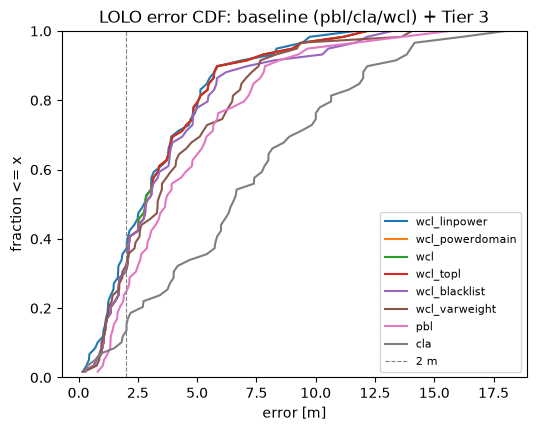

In [10]:
order = lolo_summary.sort_values("ave")["method"].tolist()
fig, ax = plt.subplots(figsize=(6, 4.5))
for method in order:
    errs = np.sort(
        lolo_ledger.loc[lolo_ledger["method"] == method, "error"].dropna().to_numpy(dtype=float)
    )
    y = np.arange(1, len(errs) + 1) / len(errs)
    ax.plot(errs, y, label=method)
ax.axvline(2.0, color="gray", linestyle="--", linewidth=0.8, label="2 m")
ax.set_xlabel("error [m]")
ax.set_ylabel("fraction <= x")
ax.set_ylim(0.0, 1.0)
ax.set_title("LOLO error CDF: baseline (pbl/cla/wcl) + Tier 3")
ax.legend(fontsize=8)
plt.show()

## 7. 負の結果の考察（仮説、未検証）

LOLO ave で見ると、Tier 3 の効果は小幅ないし悪化にとどまる：wcl_topl は同等、
wcl_linpower は微改善、wcl_blacklist・wcl_varweight は悪化する
（`doc/final_report/main.tex` §5「結果」要点）。
一次情報（`doc/final_report/main.tex` §6「考察」(c)、および各 `wcl_*.py` モジュールの
docstring/コメント）に基づき、以下は**いずれも観測結果に対する仮説であり、
対象を絞ったアブレーション（例: AP-C0-3F-04 を戻した blacklist の再実行）による
検証は未実施**である：

- **wcl_blacklist の悪化 — 情報源の喪失仮説**：廊下外に設置された AP-C0-3F-04 も
  位置固有の検出パターン（＝識別に使える情報）を持っており、これを候補から除外する
  ことは、位置推定に有用な情報を単純に捨てることに等しい、という仮説。
- **wcl_varweight の悪化 — per-query 分散推定のノイズ仮説**：1 地点あたり
  $n=10$ 回という少数スキャンから求めた分散 $\sigma_q$・検出率を重み補正に使うと、
  この推定自体がノイジーであるため、重みがかえって不安定化する、という仮説。
  `src/icsr8/methods/wcl_varweight.py` のコメント（F1/F2）にあるとおり、band 単位での
  分散・検出数の分離は実装済みだが、$n=10$ という母数の小ささ自体は解消されていない。

共通する構造的な限界として、Tier 3 のいずれの手法も WCL の**凸包制約**
（推定点が使用 AP 座標の凸包内に留まる幾何的な根本問題）を保持したままであり、
重みや入力候補をどれだけ調整しても、この制約自体は解消されない
（`doc/final_report/main.tex` §5「実装手法」3.1節）。目標の 2 m 未満達成には、
WCL の枠組みを離れた fingerprinting 系（wknn/centered_fp 等）や
gp_corridor が必要だった、というのが本報告全体の結論である。

## 8. 照合セル（必須）

上で計算した Protocol A / LOLO の指標を、凍結済み（本ノートからは書き込み禁止）の
`results/protocol_a.csv` / `results/lolo_summary.csv` の該当行と
`np.testing.assert_allclose(atol=1e-6)` で照合する。

In [11]:
ref_pa = pd.read_csv(RESULTS_DIR / "protocol_a.csv")
ref_lolo = pd.read_csv(RESULTS_DIR / "lolo_summary.csv")

ref_pa_subset = ref_pa[ref_pa["method"].isin(METHODS)]
ref_lolo_subset = ref_lolo[ref_lolo["method"].isin(METHODS)]

pa_cols = [
    "ave", "median", "p75", "p90", "max", "std",
    "within_2m", "within_4m", "ci_lo", "ci_hi",
    "delta_vs_wcl", "delta_lo", "delta_hi",
]
merged_pa_check = pa_results.merge(
    ref_pa_subset, on=["method", "fold"], suffixes=("_nb", "_ref"), validate="one_to_one"
)
assert len(merged_pa_check) == len(pa_results) == len(ref_pa_subset), (
    "Protocol A の行数が一致しません"
)
for col in pa_cols:
    np.testing.assert_allclose(
        merged_pa_check[f"{col}_nb"].to_numpy(dtype=float),
        merged_pa_check[f"{col}_ref"].to_numpy(dtype=float),
        atol=1e-6,
        err_msg=f"Protocol A column mismatch: {col}",
    )

lolo_cols = ["ave", "median", "p90", "within_2m"]
merged_lolo_check = lolo_summary.merge(
    ref_lolo_subset, on="method", suffixes=("_nb", "_ref"), validate="one_to_one"
)
assert len(merged_lolo_check) == len(lolo_summary) == len(ref_lolo_subset), (
    "LOLO の行数が一致しません"
)
for col in lolo_cols:
    np.testing.assert_allclose(
        merged_lolo_check[f"{col}_nb"].to_numpy(dtype=float),
        merged_lolo_check[f"{col}_ref"].to_numpy(dtype=float),
        atol=1e-6,
        err_msg=f"LOLO column mismatch: {col}",
    )

print(
    "一致: Protocol A（8手法 x 2 fold）と LOLO（8手法）の指標は "
    "results/protocol_a.csv, results/lolo_summary.csv と atol=1e-6 で一致しました。"
)

一致: Protocol A（8手法 x 2 fold）と LOLO（8手法）の指標は results/protocol_a.csv, results/lolo_summary.csv と atol=1e-6 で一致しました。


## 9. 所要時間の記録

In [12]:
timings["notebook_total"] = time.perf_counter() - t_notebook_start
timing_df = pd.DataFrame(
    [{"stage": k, "seconds": v} for k, v in timings.items()]
).sort_values("seconds", ascending=False).reset_index(drop=True)
timing_df

,stage,seconds
0,notebook_total,9.436879
1,lolo,8.125537
2,protocol_a,0.723840
3,equivalence_check,0.083708
4,data_load,0.025119
